In [1]:
import numpy as np
import xarray as xr
import pyart
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Circle
import glob
import sys
import os
from grf_functions import *

plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=12)
rc('figure', facecolor='white')
rc('axes', titlesize=15)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [6]:
drad = "/data/arrcwx/wrt_jtrf/morton/no_grf/"
dvort = "/data/arrcwx/wrt_jtrf/morton/sa/"
ffiles = sorted(glob.glob(f"{drad}DEALIASED*"))
nfiles = len(ffiles)
files = [os.path.basename(ffiles[jt]) for jt in range(nfiles)]
vffiles = sorted(glob.glob(f"{dvort}vortex*"))
vfiles = [os.path.basename(vffiles[jt]) for jt in range(len(vffiles))]

rall = []
el, prt, nyquist = [np.empty(nfiles) for _ in range(3)]
tplot = []
xv, yv = [np.empty(len(vffiles)) for _ in range(2)]
for jf in range(nfiles):
    radar = pyart.io.read(ffiles[jf])
    # adjust reflectivity
    ref_adj = radar.fields['DBZ']['data'] + 20
    radar.add_field_like('DBZ', 'DBZ_ADJ', ref_adj, replace_existing=True)
    # fix metadata
    radar.metadata['instrument_name'] = 'RaXPol'
    rall.append(radar)
    # store params
    el[jf] = float(radar.fixed_angle['data'])
    prt[jf] = float(radar.instrument_parameters['prt']['data'][-1])
    nyquist[jf] = 0.0308077 / (prt[jf] * 4)

    tu = radar.time['units']
    tplot.append(tu[14:-10] + " " + tu[-9:-1])

    # read vortex positions
    vortex = np.loadtxt(vffiles[jf], delimiter=',', skiprows=1)
    xv[jf], yv[jf] = vortex[0], vortex[1]

In [46]:
xc, yc = 3.21, 4.70
xw, yw = 3.5, 4.70

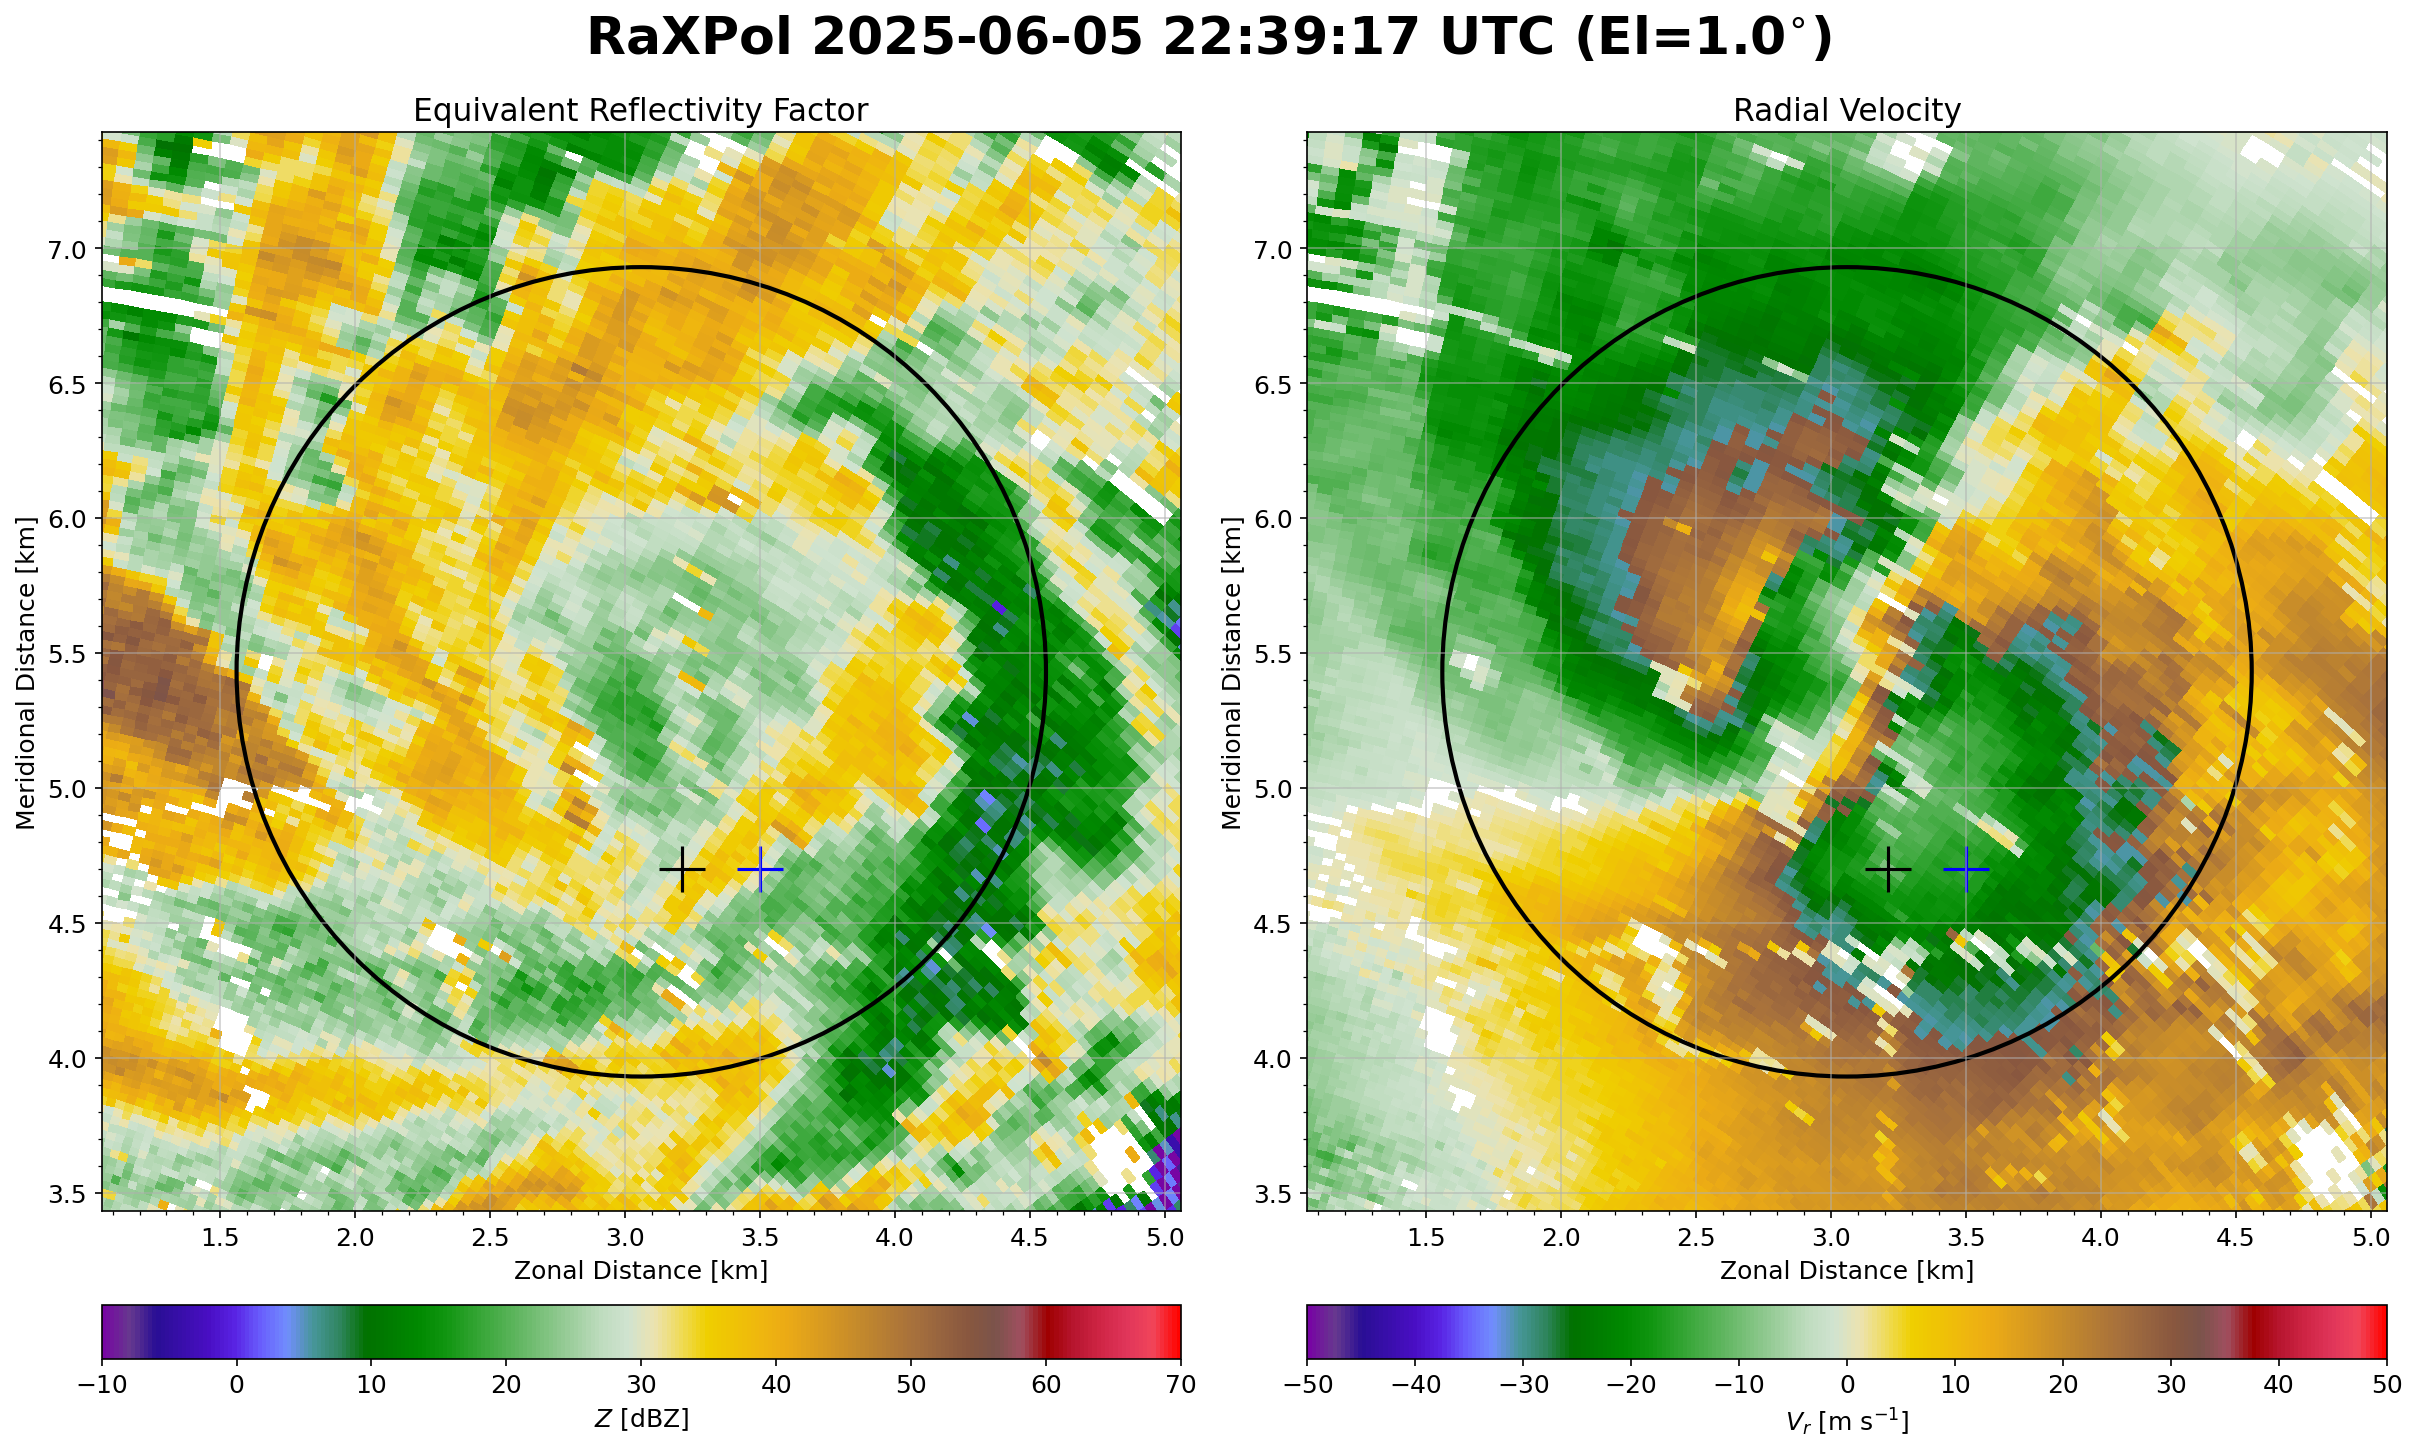

In [ ]:
# for jt, radar in enumerate(rall):
jt = 14

radar = rall[jt]
vel = radar.fields['VEL']['data']
sw = radar.fields['WIDTH']['data']
cmask = (np.abs(vel) < 0.5) & (sw < 3)
veldel = radar.fields['VELDEL']['data']
veldel_plot = np.where(cmask, np.nan, vel)#del)
ref = radar.fields['DBZ_ADJ']['data']
ref_plot = np.where(cmask, np.nan, ref)
x, y, _ = radar.get_gate_x_y_z(0)

xlims = [xv[jt]-2, xv[jt]+2]
ylims = [yv[jt]-2, yv[jt]+2]
# xlims = [xc-1, xc+1]
# ylims = [yc-1, yc+1]

gatefilter = pyart.filters.GateFilter(radar)
gatefilter.exclude_below('SNRH', -10.0)

fig, axs = plt.subplots(figsize=(16,9.5), 
                        ncols=2,
                        constrained_layout=True,
                        dpi=150)

fig.suptitle(f"{radar.metadata['instrument_name']} {tplot[jt]} UTC (El={round(el[jt],1)}$^{{\\circ}}$)", 
            fontsize=25, 
            fontweight='bold',
            y=1)

# reflectivity
ax = axs[0]
vmin, vmax = -10, 70
pcm = ax.pcolormesh(x/1e3, y/1e3, ref_plot,
                    vmin=vmin, vmax=vmax,
                    cmap='Carbone42')

cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$Z$ [dBZ]")
cbar.set_ticks(np.arange(vmin, vmax + 0.001, 10))
ax.set_title("Equivalent Reflectivity Factor")
ax.set_ylabel("Meridional Distance [km]")
# radial velocity
ax = axs[1]
vmin, vmax = -50, 50
pcm = ax.pcolormesh(x/1e3, y/1e3, veldel_plot,
                    vmin=vmin, vmax=vmax,
                    cmap='Carbone42')
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(vmin, vmax + 0.001, 10))
ax.set_title("Radial Velocity")

# clean up plot
for iax in axs.flatten():
    iax.set_aspect('equal')
    iax.set_xlim(xlims)
    iax.xaxis.set_major_locator(MultipleLocator(0.5))
    iax.xaxis.set_minor_locator(MultipleLocator(0.1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(ylims)
    iax.yaxis.set_major_locator(MultipleLocator(0.5))
    iax.yaxis.set_minor_locator(MultipleLocator(0.1))
    iax.grid(alpha=0.6)
    iax.set_ylabel("Meridional Distance [km]")
    circ = Circle((xv[jt], yv[jt]), 1.5,
                  edgecolor='black',
                  facecolor='none',
                  lw=2)
    iax.add_patch(circ)
    iax.scatter(xc, yc, s=500, c='black', marker='+')
    iax.scatter(xw, yw, s=500, c='blue', marker='+')

# finish up plot
plt.show()
plt.close(fig)

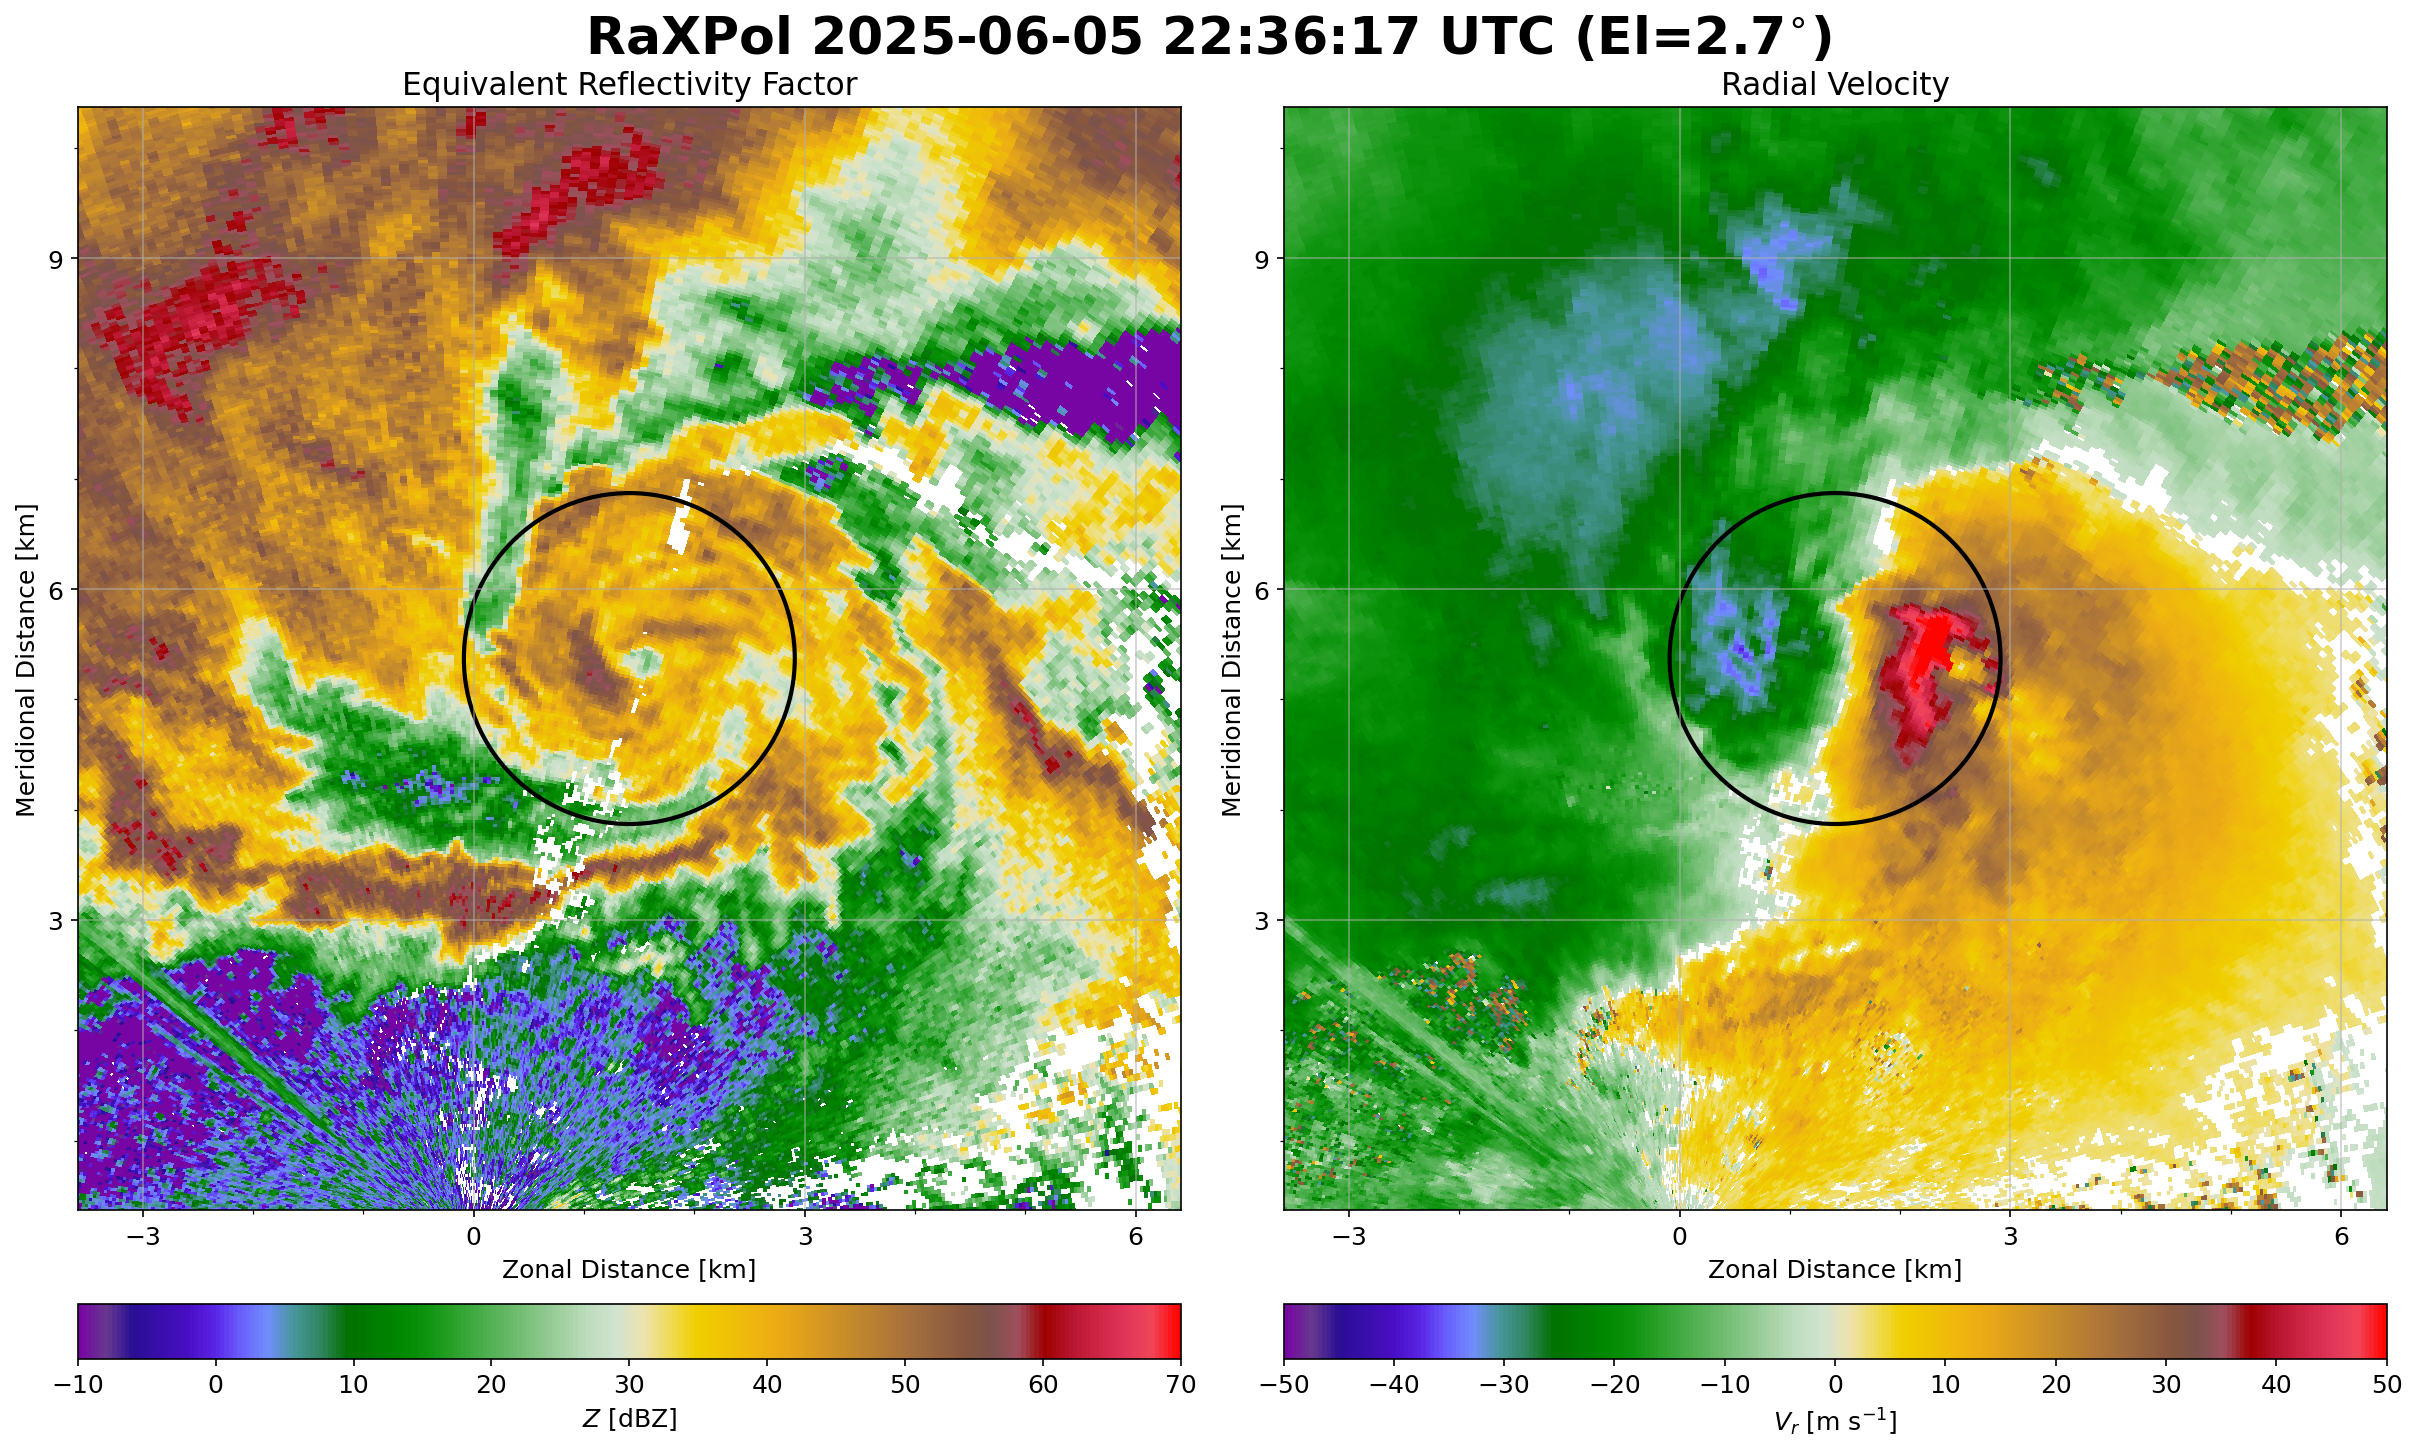

In [16]:
# for jt, radar in enumerate(rall):
jt = 5

radar = rall[jt]
vel = radar.fields['VEL']['data']
sw = radar.fields['WIDTH']['data']
rhohv = radar.fields['RHOHV']['data']
cmask = (np.abs(vel) < 2.5) & (sw < 5)# & (rhohv < 0.9)
veldel = radar.fields['VELDEL']['data']
veldel_plot = np.where(cmask, np.nan, veldel)
ref = radar.fields['DBZ_ADJ']['data']
ref_plot = np.where(cmask, np.nan, ref)
x, y, _ = radar.get_gate_x_y_z(0)

xlims = [xv[jt]-5, xv[jt]+5]
ylims = [yv[jt]-5, yv[jt]+5]

gatefilter = pyart.filters.GateFilter(radar)
gatefilter.exclude_below('SNRH', -10.0)

fig, axs = plt.subplots(figsize=(16,9.5), 
                        ncols=2,
                        constrained_layout=True,
                        dpi=150)

fig.suptitle(f"{radar.metadata['instrument_name']} {tplot[jt]} UTC (El={round(el[jt],1)}$^{{\\circ}}$)", 
            fontsize=25, 
            fontweight='bold',
            y=1)

# reflectivity
ax = axs[0]
vmin, vmax = -10, 70
pcm = ax.pcolormesh(x/1e3, y/1e3, ref_plot,
                    vmin=vmin, vmax=vmax,
                    cmap='Carbone42')

cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$Z$ [dBZ]")
cbar.set_ticks(np.arange(vmin, vmax + 0.001, 10))
ax.set_title("Equivalent Reflectivity Factor")
ax.set_ylabel("Meridional Distance [km]")
# radial velocity
ax = axs[1]
vmin, vmax = -50, 50
pcm = ax.pcolormesh(x/1e3, y/1e3, veldel_plot,
                    vmin=vmin, vmax=vmax,
                    cmap='Carbone42')
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(vmin, vmax + 0.001, 10))
ax.set_title("Radial Velocity")

# clean up plot
for iax in axs.flatten():
    iax.set_aspect('equal')
    iax.set_xlim(xlims)
    iax.xaxis.set_major_locator(MultipleLocator(3))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(ylims)
    iax.yaxis.set_major_locator(MultipleLocator(3))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.grid(alpha=0.6)
    iax.set_ylabel("Meridional Distance [km]")
    circ = Circle((xv[jt], yv[jt]), 1.5,
                  edgecolor='black',
                  facecolor='none',
                  lw=2)
    iax.add_patch(circ)

# finish up plot
plt.show()
plt.close(fig)